# Exploratory Data Analysis (EDA)

This section explores pricing and rating patterns in the dataset
to identify trends and relationships that could inform business
decisions such as pricing strategy, product positioning, and experimentation.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
PROJECT_ROOT = Path("..").resolve()
clean_path = PROJECT_ROOT / "data" / "processed" / "books_clean.csv"

df = pd.read_csv(clean_path)
df.head()




,title,price_gbp,rating,url,page_num,rating_num,title_length,high_rating
0,A Light in the Attic,51.77,Three,https://books.toscrape.com/catalogue/a-light-i...,1,3,20,0
1,Tipping the Velvet,53.74,One,https://books.toscrape.com/catalogue/tipping-t...,1,1,18,0
2,Soumission,50.10,One,https://books.toscrape.com/catalogue/soumissio...,1,1,10,0
3,Sharp Objects,47.82,Four,https://books.toscrape.com/catalogue/sharp-obj...,1,4,13,1
4,Sapiens: A Brief History of Humankind,54.23,Five,https://books.toscrape.com/catalogue/sapiens-a...,1,5,37,1


EDA was performed on a processed dataset generated by the cleaning pipeline

In [8]:
df["price_gbp"].describe()


count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: price_gbp, dtype: float64

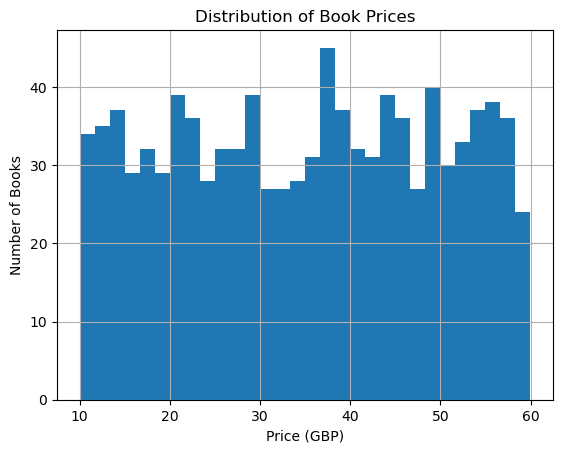

In [9]:
plt.figure()
df["price_gbp"].hist(bins=30)
plt.xlabel("Price (GBP)")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")
plt.show()


**Insight:**  
Book prices show a right-skewed distribution, with most titles concentrated
in a mid-price range and a smaller number of higher-priced outliers.


In [10]:
df.groupby("rating_num")["price_gbp"].mean()


rating_num
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price_gbp, dtype: float64

<Figure size 640x480 with 0 Axes>

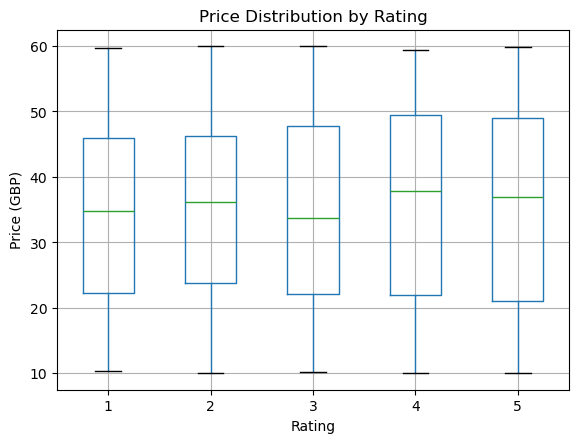

In [11]:
plt.figure()
df.boxplot(column="price_gbp", by="rating_num")
plt.xlabel("Rating")
plt.ylabel("Price (GBP)")
plt.title("Price Distribution by Rating")
plt.suptitle("")  # quita título automático
plt.show()


**Insight:**  
Higher-rated books tend to have slightly higher average prices,
although there is significant overlap across rating levels.


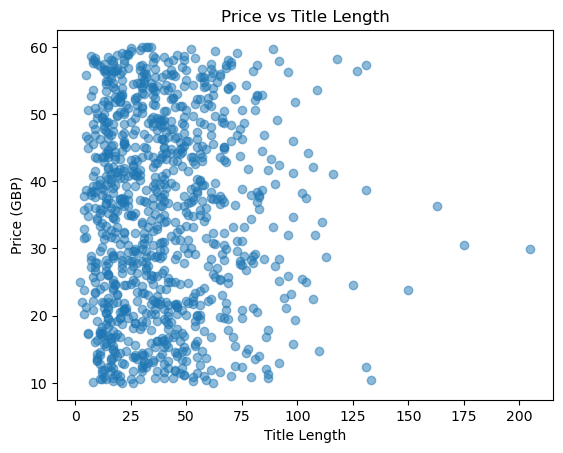

In [12]:
plt.figure()
plt.scatter(df["title_length"], df["price_gbp"], alpha=0.5)
plt.xlabel("Title Length")
plt.ylabel("Price (GBP)")
plt.title("Price vs Title Length")
plt.show()


**Insight:**  
There is no strong linear relationship between title length and price,
suggesting that pricing is not influenced by title complexity alone.


**Note:**  
Category analysis was identified as a next step, as it requires scraping individual product pages. For this phase, I focused on pricing and rating patterns supported by the available data


## Key Takeaways

- Book prices are not evenly distributed and cluster around a mid-price range.
- Rating alone does not fully explain pricing differences across books.
- These patterns suggest opportunities for controlled pricing experiments
  and simulated A/B testing rather than assumptions based solely on ratings.
